# Getting started with T0

T0 is an open-weights time-series foundation model from [The Forecasting Company](https://huggingface.co/theforecastingcompany/t0-alpha).
It produces probabilistic multi-horizon forecasts natively with support for known-future covariates (calendar features, weather, planned events, etc.).

This notebook mirrors the [Chronos-2 quickstart](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb) in structure, using the same canonical datasets:

1. **M4 hourly** (`m4_hourly/train.csv`) — univariate forecasting
2. **Electricity price** (`electricity_price/{train,test}.parquet`) — the same target + two future-known day-ahead forecasts of load and renewable generation used in Chronos-2's covariates section

If the network is unavailable, both cells fall back to a small synthetic series so the notebook still runs end-to-end.

**Setup.** From the repo root:

```bash
pip install -e '.[notebooks]'
```


In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from t0 import T0Forecaster

# Silence two harmless warnings that would otherwise leak absolute paths into
# the notebook outputs:
#   - PyTorch: t0.predict() wraps non-contiguous numpy views in torch.as_tensor
#   - tqdm: "IProgress not found" — only relevant in classic Jupyter, not Colab
warnings.filterwarnings("ignore", message=".*not writable.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*", category=Warning)

## Load the model


In [2]:
t0 = time.time()
model = T0Forecaster.from_pretrained("theforecastingcompany/t0-alpha").eval()
print(f"loaded in {time.time() - t0:.1f}s, {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params")

loaded in 1.7s, 101.6M params


## 1. Univariate forecasting on M4 hourly

Same dataset as the Chronos-2 quickstart: 414 hourly series, 700 points each. We pick one series, hold out the last 48 hours as ground truth, and ask T0 to forecast.


In [3]:
M4_URL = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv"
FALLBACK_LENGTH = 560  # 512 context + 48 horizon — multiple of patch_size=32

try:
    m4 = pd.read_csv(M4_URL)
    series_id = m4["item_id"].iloc[0]
    full = m4.loc[m4["item_id"] == series_id, "target"].to_numpy(dtype=np.float32)
    print(f"loaded M4 hourly from {M4_URL}: {m4.shape}, picked series {series_id!r}, length {len(full)}")
    ctx_len, horizon = 512, 48
    ctx, true_fut = full[:ctx_len][None], full[ctx_len : ctx_len + horizon][None]
except Exception as e:
    print(f"network load failed ({e}); using synthetic fallback")
    torch.manual_seed(0)
    t = np.arange(FALLBACK_LENGTH + 48, dtype=np.float32)
    ctx = (
        np.sin(2 * np.pi * t[:FALLBACK_LENGTH] / 50) + 0.1 * np.random.default_rng(0).standard_normal(FALLBACK_LENGTH)
    )[None]
    true_fut = (np.sin(2 * np.pi * t[FALLBACK_LENGTH:] / 50) + 0.1 * np.random.default_rng(1).standard_normal(48))[None]
    ctx_len, horizon = FALLBACK_LENGTH, 48

print(f"ctx shape={ctx.shape}, horizon={horizon}")

loaded M4 hourly from https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv: (353500, 3), picked series 'H1', length 700
ctx shape=(1, 512), horizon=48


In [4]:
t0 = time.time()
out = model.predict(ctx, horizon=horizon, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(f"predict in {time.time() - t0:.2f}s, q.shape={tuple(out.quantiles.shape)}")

predict in 0.16s, q.shape=(1, 48, 5)


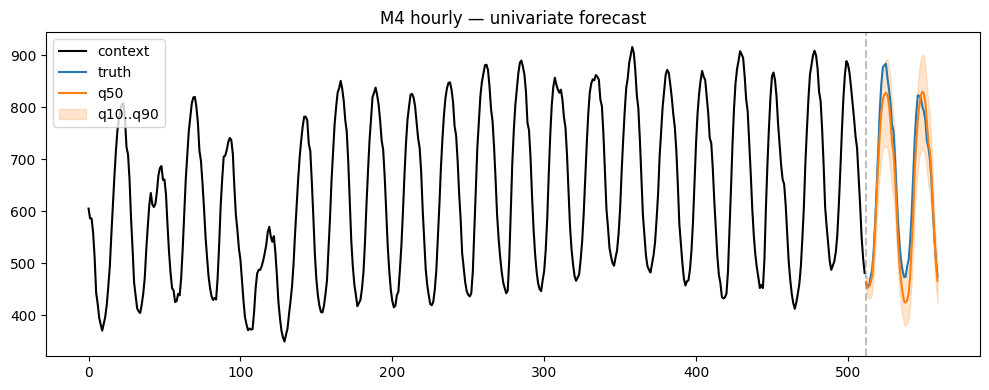

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ctx[0], label="context", color="black")
ax.plot(np.arange(ctx_len, ctx_len + horizon), true_fut[0], label="truth", color="#1f77b4")
ax.plot(np.arange(ctx_len, ctx_len + horizon), out.quantiles[0, :, 2], label="q50", color="#ff7f0e")
ax.fill_between(
    np.arange(ctx_len, ctx_len + horizon),
    out.quantiles[0, :, 0],
    out.quantiles[0, :, 4],
    color="#ff7f0e",
    alpha=0.2,
    label="q10..q90",
)
ax.axvline(ctx_len, color="gray", linestyle="--", alpha=0.5)
ax.set_title("M4 hourly — univariate forecast")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Forecasting with covariates on the electricity-price dataset

Same setup as Chronos-2's energy-price section: the target is hourly day-ahead electricity price; the two day-ahead forecasts of load (`Ampirion Load Forecast`) and renewable generation (`PV+Wind Forecast`) are known over the test horizon. T0 conditions on the past values of both and is told their future values.


In [6]:
EP_TRAIN_URL = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
EP_TEST_URL = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"

try:
    ep_train = pd.read_parquet(EP_TRAIN_URL)
    ep_test = pd.read_parquet(EP_TEST_URL)
    print(f"loaded electricity_price: train {ep_train.shape}, test {ep_test.shape}")
    cov_cols = [c for c in ep_test.columns if c not in ("id", "timestamp", "target")]
    print(f"future-known covariates: {cov_cols}")

    # Take the most recent 512 hours of the training series as context,
    # then ask the model to forecast the next 24 hours (the test horizon).
    ctx_len, horizon = 512, len(ep_test)
    ctx_series = ep_train["target"].to_numpy(dtype=np.float32)[-ctx_len:]
    # Build the covariates tensor: past values (over the context) + future
    # values (from the test split). Past part is from train, future from test.
    cov_past = ep_train[cov_cols].to_numpy(dtype=np.float32)[-ctx_len:].T  # [F, ctx_len]
    cov_fut = ep_test[cov_cols].to_numpy(dtype=np.float32).T  # [F, horizon]
    cov = np.concatenate([cov_past, cov_fut], axis=1)  # [F, ctx_len + horizon]
    true_fut = ep_test["target"].to_numpy(dtype=np.float32)[None]
    ctx = ctx_series[None]
    print(f"ctx={ctx.shape}, cov={cov.shape}, true_fut={true_fut.shape}")
except Exception as e:
    print(f"network load failed ({e}); using synthetic fallback")
    torch.manual_seed(1)
    ctx_len, horizon = 512, 24
    t = np.arange(ctx_len + horizon, dtype=np.float32)
    ctx = (np.sin(2 * np.pi * t[:ctx_len] / 50) + 0.1 * np.random.default_rng(2).standard_normal(ctx_len))[None]
    true_fut = (np.sin(2 * np.pi * t[ctx_len:] / 50) + 0.1 * np.random.default_rng(3).standard_normal(horizon))[None]
    # Two synthetic future-known covariates (phase-shifted sines), mirroring the
    # two day-ahead forecasts in the real dataset -> [F=2, ctx_len + horizon].
    cov = np.stack(
        [np.sin(2 * np.pi * (t - 5) / 50), np.cos(2 * np.pi * t / 50)]
    ).astype(np.float32)  # [2, ctx_len + horizon]
    print(f"(synthetic) cov={cov.shape}")

loaded electricity_price: train (51936, 5), test (24, 5)
future-known covariates: ['Ampirion Load Forecast', 'PV+Wind Forecast']
ctx=(1, 512), cov=(2, 536), true_fut=(1, 24)


In [7]:
t0 = time.time()
out_no_cov = model.predict(ctx, horizon=horizon, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(f"predict(no cov)   in {time.time() - t0:.2f}s")
t0 = time.time()
out_cov = model.predict(
    ctx, horizon=horizon, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9], future_covariates=torch.as_tensor(cov)[None]
)
print(f"predict(w/  cov)  in {time.time() - t0:.2f}s")

predict(no cov)   in 0.07s
predict(w/  cov)  in 0.07s


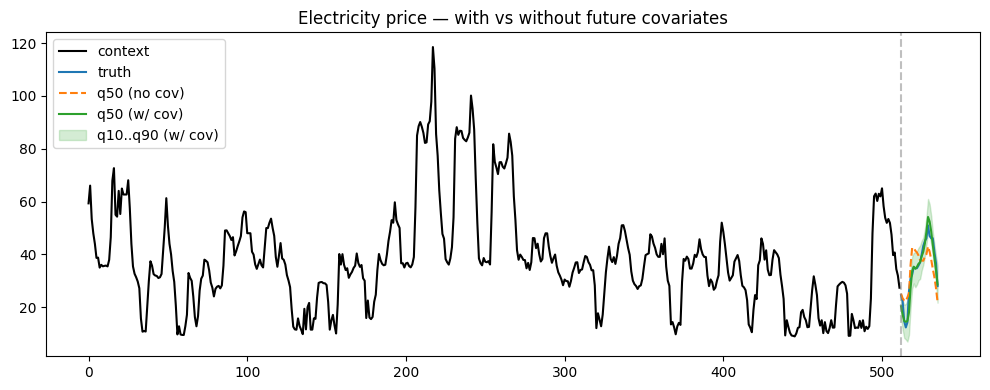

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ctx[0], label="context", color="black")
ax.plot(np.arange(ctx_len, ctx_len + horizon), true_fut[0], label="truth", color="#1f77b4")
ax.plot(
    np.arange(ctx_len, ctx_len + horizon),
    out_no_cov.quantiles[0, :, 2],
    label="q50 (no cov)",
    color="#ff7f0e",
    linestyle="--",
)
ax.plot(np.arange(ctx_len, ctx_len + horizon), out_cov.quantiles[0, :, 2], label="q50 (w/ cov)", color="#2ca02c")
ax.fill_between(
    np.arange(ctx_len, ctx_len + horizon),
    out_cov.quantiles[0, :, 0],
    out_cov.quantiles[0, :, 4],
    color="#2ca02c",
    alpha=0.2,
    label="q10..q90 (w/ cov)",
)
ax.axvline(ctx_len, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Electricity price — with vs without future covariates")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Dtype routing (1.x hub API)

`from_pretrained` accepts a `dtype` kwarg via the `huggingface_hub` 1.x mixin. bf16/fp16 keep fp32 master weights and autocast the forward inside `predict`; fp32 is the default.


In [9]:
for label, dt in [("default fp32", None), ("bf16 (autocast)", torch.bfloat16), ("fp16 (autocast)", torch.float16)]:
    kw = {"dtype": dt} if dt is not None else {}
    m = T0Forecaster.from_pretrained("theforecastingcompany/t0-alpha", **kw).eval()
    p = next(m.parameters())
    with torch.no_grad():
        o = m.predict(ctx, horizon=horizon, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    err = (o.median - torch.as_tensor(true_fut)).abs().mean().item()
    print(f"  {label:20s}  weights={str(p.dtype):16s}  |median-truth|={err:.3f}")

  default fp32          weights=torch.float32     |median-truth|=6.168
  bf16 (autocast)       weights=torch.float32     |median-truth|=6.192
  fp16 (autocast)       weights=torch.float32     |median-truth|=6.169


## Next

See `02_finetune_lora.ipynb` for parameter-efficient fine-tuning of the model with PEFT/LoRA on the [Chronos-2 retail-sales](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb) dataset (the same one used by the TimesFM finetuning example).
